<a href="https://colab.research.google.com/github/sebitajuniorprogramax-byte/nube-palabras-cafe/blob/main/Quetegustadelcafe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fpdf
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
MODO_IMPORTACION = True

# Al ejecutar esto, no verás ningún mensaje de error ni tracebacks rojos
%run "/content/drive/MyDrive/Proyectos/machine learning/ProyectoIAGenerativa/Asistente_AnalisisDTS.ipynb"

Estructura y Librerías cargadas. Saltando fase de pruebas automáticamente.


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


SystemExit: 

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


SystemExit: 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Conexión exitosa. Analizando columna: 'Cómo te gusta el café'


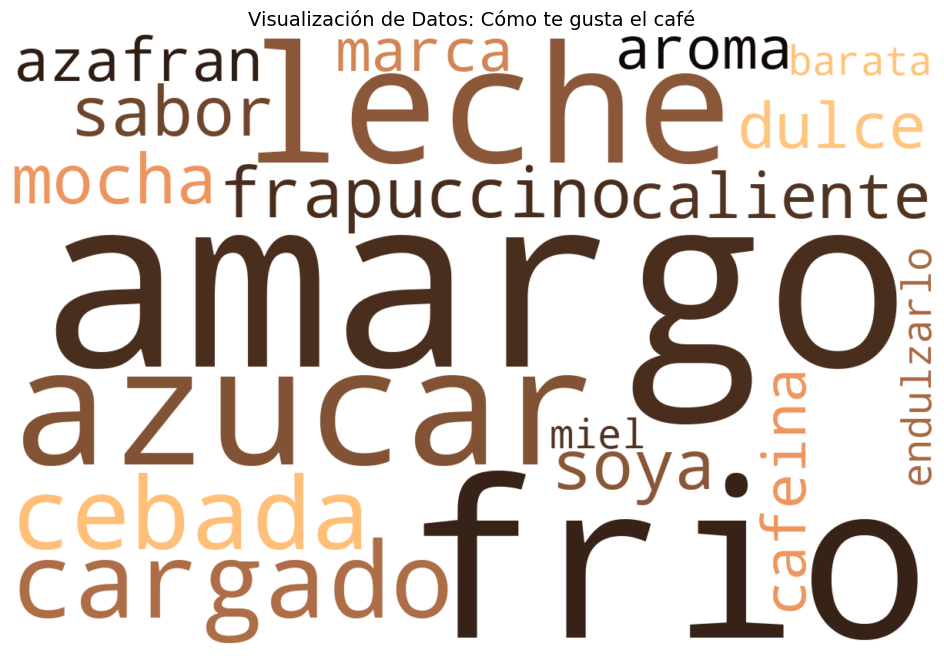


Iniciando análisis de datos de la cafetería...

--- INFORME ESTRATÉGICO ---
Como experto analista de datos y estratega, he procesado la información de la **Tag Cloud** proporcionada. A continuación, presento el desglose técnico y estratégico solicitado:

### 1. Contexto (Título e Interpretación)
Aunque la imagen no presenta un título externo en una caja de texto separada, las palabras en la franja superior (**azafrán, marca, aroma, barata**) y el cuerpo general definen claramente el contexto: **"Preferencias y Hábitos de Consumo de Café y Bebidas Relacionadas"**. 

### 2. Análisis de Sentimiento (Enfoque en Preferencias)
Siguiendo las instrucciones, los términos no se califican como críticas, sino como atributos de valor para el consumidor:
*   **Neutral/Positivo (Perfil de Sabor):** "Amargo", "cargado" y "aroma" representan la búsqueda de intensidad.
*   **Neutral/Positivo (Experiencia):** "Frío" y "caliente" indican versatilidad estacional.
*   **Conveniencia:** "Barata" y "marca" s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =================================================================
# 1. AUTENTICACIÓN Y LIBRERÍAS
# =================================================================
from google.colab import auth, userdata, files
import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from fpdf import FPDF
import unicodedata

# Descarga de recursos necesarios
auth.authenticate_user()
nltk.download('stopwords')

# =================================================================
# 2. CONEXIÓN A GOOGLE SHEETS
# =================================================================
creds, _ = default()
gc = gspread.authorize(creds)
nombre_archivo = 'Que te gusta más del café (Respuestas)'

try:
    spreadsheet = gc.open(nombre_archivo)
    sheet = spreadsheet.get_worksheet(0)
    df = pd.DataFrame(sheet.get_all_records())
    columna_datos = df.columns[1]
    print(f"Conexión exitosa. Analizando columna: '{columna_datos}'")
except Exception as e:
    print(f"Error de conexión: {e}")

# =================================================================
# 3. FILTRADO Y ASIMILACIÓN DE TILDES (NLP)
# =================================================================
def limpiar_respuestas(dataframe, nombre_col):
    # Unimos texto y pasamos a minúsculas
    texto = " ".join(dataframe[nombre_col].astype(str)).lower()

    # NORMALIZACIÓN TÉCNICA: Elimina tildes para asimilar palabras (ej: café -> cafe)
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                  if unicodedata.category(c) != 'Mn')

    # Limpieza de caracteres especiales
    texto = re.sub(r'[^a-z\s]', '', texto)

    stop_words = set(stopwords.words('spanish'))
    relleno_especifico = [
        'favorito', 'masomenos', 'dos', 'cucharadas', 'con', 'del', 'que',
        'para', 'una', 'este', 'esta', 'los', 'las', 'como', 'gustar', 'cafe',
        'hace', 'suelo', 'rica', 'cafes', 'gusta', 'encanta', 'ecco', 'manera', 'bien'
    ]
    stop_words.update(relleno_especifico)

    palabras_limpias = [w for w in texto.split() if w not in stop_words and len(w) > 2]
    return " ".join(palabras_limpias)

texto_para_nube = limpiar_respuestas(df, columna_datos)

# =================================================================
# 4. GENERACIÓN Y VISUALIZACIÓN DE LA NUBE (IMPORTANTE)
# =================================================================
wc = WordCloud(
    width=1200, height=800,
    background_color='white',
    colormap='copper',
    max_words=50,
    contour_width=2,
    contour_color='saddlebrown'
).generate(texto_para_nube)

# MOSTRAR EN EL PANEL DE COLAB
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title(f"Visualización de Datos: {columna_datos}", fontsize=14)
plt.show() # Este comando activa la visualización en el panel

# Guardado para el PDF y el Asistente
nombre_imagen = "resultado_cafeteria.png"
wc.to_file(nombre_imagen)

# =================================================================
# 5. ANÁLISIS ESTRATÉGICO (CON USERDATA)
# =================================================================
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    asistente = AsistenteVisual(api_key=api_key)

    print("\nIniciando análisis de datos de la cafetería...")
    # Pasamos el nombre de la columna como título para dar contexto
    resultado = asistente.analizar_TagCloud(nombre_imagen)

    print("\n--- INFORME ESTRATÉGICO ---")
    print(resultado)
except Exception as e:
    print(f"Error en el análisis de IA: {e}")

# =================================================================
# 6. GENERACIÓN DE REPORTE PDF
# =================================================================
def generar_pdf(imagen, texto, salida="Reporte_Final_Cafe.pdf"):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", 'B', 16)
    pdf.cell(0, 10, "Informe de Análisis de Preferencias", 0, 1, 'C')
    pdf.ln(10)

    # Insertar Imagen
    pdf.set_font("Arial", 'B', 12)
    pdf.cell(0, 10, "1. Nube de Palabras (Asimilada):", 0, 1)
    pdf.image(imagen, x=10, y=None, w=180)
    pdf.ln(10)

    # Insertar Texto (Nueva página para el informe largo)
    pdf.add_page()
    pdf.cell(0, 10, "2. Análisis Técnico del Asistente:", 0, 1)
    pdf.set_font("Arial", size=11)
    pdf.multi_cell(0, 10, texto.encode('latin-1', 'replace').decode('latin-1'))

    pdf.output(salida)
    return salida

if 'resultado' in locals():
    archivo_pdf = generar_pdf(nombre_imagen, resultado)
    print(f"\nPDF creado exitosamente: {archivo_pdf}")
    files.download(archivo_pdf)

# **Respaldo**

In [ ]:
# # =================================================================
# # 1. autenticación y librerias
# # =================================================================
# from google.colab import auth
# auth.authenticate_user()

# import gspread
# from google.auth import default
# import pandas as pd
# import matplotlib.pyplot as plt
# from wordcloud import WordCloud
# import re
# import nltk
# from nltk.corpus import stopwords

# # Recursos para procesamiento de lenguaje natural (NLP)
# nltk.download('stopwords')

# # =================================================================
# # 2. CONEXIÓN ROBUSTA A GOOGLE SHEETS
# # =================================================================
# creds, _ = default()
# gc = gspread.authorize(creds)

# # Usamos el nombre exacto del archivo
# nombre_archivo = 'Que te gusta más del café (Respuestas)'

# try:
#     spreadsheet = gc.open(nombre_archivo)
#     sheet = spreadsheet.get_worksheet(0)
#     df = pd.DataFrame(sheet.get_all_records())

#     columna_datos = df.columns[1]
#     print(f"Conexión exitosa. Analizando columna: '{columna_datos}'")

# except Exception as e:
#     print(f"Error de conexión: {e}")

# # =================================================================
# # 3. FILTRADO Y LIMPIEZA PROFESIONAL (ANALISIS DE DATOS)
# # =================================================================
# def limpiar_respuestas(dataframe, nombre_col):
#     # Unimos todo el texto
#     texto = " ".join(dataframe[nombre_col].astype(str)).lower()

#     # Limpieza de caracteres especiales y números
#     texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)

#     # Configuración de Stop Words (Palabras de relleno)
#     stop_words = set(stopwords.words('spanish'))

#     # Agregamos palabras de relleno detectadas
#     relleno_especifico = [
#         'favorito', 'masomenos', 'dos', 'cucharadas', 'con', 'del', 'que',
#         'para', 'una', 'este', 'esta', 'los', 'las', 'como', 'gustar', 'cafe', 'hace', 'suelo', 'rica', 'café', 'cafés', 'gusta', 'encanta', 'ecco', 'manera', 'bien'
#     ]
#     stop_words.update(relleno_especifico)

#     # Filtrado final
#     palabras_limpias = [w for w in texto.split() if w not in stop_words and len(w) > 2]
#     return " ".join(palabras_limpias)

# texto_para_nube = limpiar_respuestas(df, columna_datos)

# # =================================================================
# # 4. GENERACIÓN DE LA NUBE DE PALABRAS
# # =================================================================
# # Colores personalizados (Paleta "Copper" para estética de cafetería)
# wc = WordCloud(
#     width=1200,
#     height=800,
#     background_color='white',
#     colormap='copper',
#     max_words=50,
#     contour_width=2,
#     contour_color='saddlebrown'
# ).generate(texto_para_nube)

# # Visualización
# plt.figure(figsize=(15, 10))
# plt.imshow(wc, interpolation='bilinear')
# plt.axis("off")
# plt.title(f"Preferencia del cliente: {columna_datos}", fontsize=18, pad=20)
# plt.show()

# # Guardar automáticamente para redes sociales
# wc.to_file("resultado_cafeteria.png")